## Contents
1. Setup & imports
2. Data loading
3. Column selection & renaming
4. Data cleaning
5. Feature engineering
6. Global analysis — languages, databases, platforms
7. Hiring priorities
8. Soft skills
9. Experience distribution
10. Country-level analysis
11. Key findings

## 1. Setup & Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 2. Data Loading

In [2]:
df = pd.read_csv("survey_results_public.csv")
print(f"Shape: {df.shape}")
df.head(3)

Shape: (51392, 154)


,Respondent,Professional,ProgramHobby,Country,University,EmploymentStatus,FormalEducation,MajorUndergrad,HomeRemote,CompanySize,...,StackOverflowMakeMoney,Gender,HighestEducationParents,Race,SurveyLong,QuestionsInteresting,QuestionsConfusing,InterestedAnswers,Salary,ExpectedSalary
0,1,Student,"Yes, both",United States,No,"Not employed, and not looking for work",Secondary school,NaN,NaN,NaN,...,Strongly disagree,Male,High school,White or of European descent,Strongly disagree,Strongly agree,Disagree,Strongly agree,NaN,NaN
1,2,Student,"Yes, both",United Kingdom,"Yes, full-time",Employed part-time,Some college/university study without earning ...,Computer science or software engineering,"More than half, but not all, the time",20 to 99 employees,...,Strongly disagree,Male,A master's degree,White or of European descent,Somewhat agree,Somewhat agree,Disagree,Strongly agree,NaN,37500.0
2,3,Professional developer,"Yes, both",United Kingdom,No,Employed full-time,Bachelor's degree,Computer science or software engineering,"Less than half the time, but at least one day ...","10,000 or more employees",...,Disagree,Male,A professional degree,White or of European descent,Somewhat agree,Agree,Disagree,Agree,113750.0,NaN


In [3]:
pd.set_option('display.max_rows', None)

col_df = pd.DataFrame({
    'No': range(1, len(df.columns) + 1),
    'Column Name': df.columns,
    'Type': df.dtypes.values
})
print(col_df.to_string(index=False))

 No                      Column Name    Type
  1                       Respondent   int64
  2                     Professional  object
  3                     ProgramHobby  object
  4                          Country  object
  5                       University  object
  6                 EmploymentStatus  object
  7                  FormalEducation  object
  8                   MajorUndergrad  object
  9                       HomeRemote  object
 10                      CompanySize  object
 11                      CompanyType  object
 12                     YearsProgram  object
 13                    YearsCodedJob  object
 14                YearsCodedJobPast  object
 15                    DeveloperType  object
 16                 WebDeveloperType  object
 17              MobileDeveloperType  object
 18                 NonDeveloperType  object
 19               CareerSatisfaction float64
 20                  JobSatisfaction float64
 21                    ExCoderReturn  object
 22       

## 3. Column Selection

The raw survey contains 154 columns. Keep only the features relevant to skills, hiring, and job-market context.

In [4]:
keep_columns = [
    # Job titles (what job role)
    'DeveloperType',
    'WebDeveloperType',
    'MobileDeveloperType',
    
    # Skills (requirements)
    'HaveWorkedLanguage',
    'HaveWorkedFramework',
    'HaveWorkedDatabase',
    'HaveWorkedPlatform',
    
    # Trending skills (what to learn next)
    'WantWorkLanguage',
    'WantWorkFramework',
    'WantWorkDatabase',
    'WantWorkPlatform',
    
    # Hiring requirements (what employers prioritize)
    'ImportantHiringAlgorithms',
    'ImportantHiringTechExp',
    'ImportantHiringCommunication',
    'ImportantHiringOpenSource',
    'ImportantHiringEducation',
    'ImportantHiringGettingThingsDone',
    
    # Soft skills (your differentiator)
    'ProblemSolving',
    'BuildingThings',
    'LearningNewTech',
    'InvestTimeTools',
    'CollaborateRemote',
    
    # Compensation & experience
    'Salary',
    'Currency',
    'YearsCodedJob',
    'Country',
    
]

print(f"Total columns to keep: {len(keep_columns)}")
df_clean = df[keep_columns]
df_clean.head()
df_clean.info()

Total columns to keep: 26
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51392 entries, 0 to 51391
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   DeveloperType                     36125 non-null  object 
 1   WebDeveloperType                  10696 non-null  object 
 2   MobileDeveloperType               1553 non-null   object 
 3   HaveWorkedLanguage                36625 non-null  object 
 4   HaveWorkedFramework               20229 non-null  object 
 5   HaveWorkedDatabase                29452 non-null  object 
 6   HaveWorkedPlatform                29114 non-null  object 
 7   WantWorkLanguage                  33771 non-null  object 
 8   WantWorkFramework                 23331 non-null  object 
 9   WantWorkDatabase                  25109 non-null  object 
 10  WantWorkPlatform                  27884 non-null  object 
 11  ImportantHiringAlgorithms         28642 n

In [5]:
# Rename columns to cleaner names
df_clean = df_clean.rename(columns={
    'DeveloperType': 'job_title',
    'WebDeveloperType': 'web_dev_specialty',
    'MobileDeveloperType': 'mobile_dev_specialty',
    'HaveWorkedLanguage': 'skills_languages',
    'HaveWorkedFramework': 'skills_frameworks',
    'HaveWorkedDatabase': 'skills_databases',
    'HaveWorkedPlatform': 'skills_platforms',
    'WantWorkLanguage': 'wanted_languages',
    'WantWorkFramework': 'wanted_frameworks',
    'WantWorkDatabase': 'wanted_databases',
    'WantWorkPlatform': 'wanted_platforms',
    'ImportantHiringAlgorithms': 'hiring_algorithms',
    'ImportantHiringTechExp': 'hiring_tech_exp',
    'ImportantHiringCommunication': 'hiring_communication',
    'ImportantHiringOpenSource': 'hiring_opensource',
    'ImportantHiringEducation': 'hiring_education',
    'ImportantHiringGettingThingsDone': 'hiring_execution',
    'ProblemSolving' : 'problem_solving',
    'BuildingThings' : 'building_things',
    'LearningNewTech' : 'learning_new_tech',
    'InvestTimeTools' : 'invest_time_tools',
    'CollaborateRemote' : 'collaborate_remote',
    'Salary': 'salary_usd',
    'Currency': 'salary_currency',
    'YearsCodedJob': 'years_coding_professionally',
    'Country': 'country'
})

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51392 entries, 0 to 51391
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   job_title                    36125 non-null  object 
 1   web_dev_specialty            10696 non-null  object 
 2   mobile_dev_specialty         1553 non-null   object 
 3   skills_languages             36625 non-null  object 
 4   skills_frameworks            20229 non-null  object 
 5   skills_databases             29452 non-null  object 
 6   skills_platforms             29114 non-null  object 
 7   wanted_languages             33771 non-null  object 
 8   wanted_frameworks            23331 non-null  object 
 9   wanted_databases             25109 non-null  object 
 10  wanted_platforms             27884 non-null  object 
 11  hiring_algorithms            28642 non-null  object 
 12  hiring_tech_exp              28694 non-null  object 
 13  hiring_communica

## 4. Data Cleaning

In [6]:
df_clean.isnull().sum() 

job_title                      15267
web_dev_specialty              40696
mobile_dev_specialty           49839
skills_languages               14767
skills_frameworks              31163
skills_databases               21940
skills_platforms               22278
wanted_languages               17621
wanted_frameworks              28061
wanted_databases               26283
wanted_platforms               23508
hiring_algorithms              22750
hiring_tech_exp                22698
hiring_communication           22753
hiring_opensource              22796
hiring_education               22729
hiring_execution               22847
problem_solving                20099
building_things                20158
learning_new_tech              20088
invest_time_tools              20506
collaborate_remote             21935
salary_usd                     38501
salary_currency                29984
years_coding_professionally    10502
country                            0
dtype: int64

In [7]:
df_clean["country"].value_counts()

country
United States                     11455
India                              5197
United Kingdom                     4395
Germany                            4143
Canada                             2233
France                             1740
Poland                             1290
Australia                           913
Russian Federation                  873
Spain                               864
Netherlands                         855
Italy                               781
Brazil                              777
Sweden                              611
Switzerland                         595
Israel                              575
Romania                             561
Iran                                507
Austria                             477
Pakistan                            454
Czech Republic                      411
Belgium                             404
South Africa                        380
Turkey                              363
Ukraine                         

### 4.1 Column dictionary

Document what each retained column represents.

In [8]:
column_dictionary = {
    # Job role
    'job_title': 'What type of developer is the respondent? (e.g., Back-end, Front-end, Data scientist)',
    
    # Hard skills
    'skills_languages': 'Programming languages the respondent currently uses ',
    'skills_frameworks': 'Frameworks the respondent currently uses',
    'skills_databases': 'Databases the respondent currently uses',
    'skills_platforms': 'Platforms/cloud services the respondent uses',
    
    # Trending skills
    'wanted_languages': 'Programming languages the respondent wants to learn next',
    'wanted_frameworks': 'Frameworks the respondent wants to learn next',
    'wanted_databases': 'Databases the respondent wants to learn next',
    'wanted_platforms': 'Platforms the respondent wants to learn next',
    
    # Hiring priorities (what employers value)
    'hiring_algorithms_importance': 'How important are algorithms skills in hiring?',
    'hiring_tech_exp_importance': 'How important is technical experience in hiring?',
    'hiring_communication_importance': 'How important are communication skills in hiring?',
    'hiring_opensource_importance': 'How important is open source contribution in hiring?',
    'hiring_education_importance': 'How important is formal education in hiring?',
    'hiring_execution_importance': 'How important is "getting things done" in hiring?',
    
    # Soft skills
    'problem_solving': 'Does the respondent enjoy solving complex problems?',
    'building_things': 'Does the respondent enjoy building/creating things?',
    'learning_new_tech': 'Does the respondent enjoy learning new technologies?',
    'invest_time_tools': 'Does the respondent invest time in learning new tools?',
    'collaborate_remote': 'Is the respondent comfortable with remote collaboration?',
    
    # Context
    'years_coding_professionally': 'How many years has the respondent been coding professionally?',
    'country': 'Country where the respondent lives'
}

In [9]:
column_info = pd.DataFrame([
    {'Column': col, 'Description': desc} 
    for col, desc in column_dictionary.items()
])

print("COLUMN DICTIONARY")
print("="*117)
print(column_info.to_string(index=False))

COLUMN DICTIONARY
                         Column                                                                           Description
                      job_title What type of developer is the respondent? (e.g., Back-end, Front-end, Data scientist)
               skills_languages                                  Programming languages the respondent currently uses 
              skills_frameworks                                              Frameworks the respondent currently uses
               skills_databases                                               Databases the respondent currently uses
               skills_platforms                                          Platforms/cloud services the respondent uses
               wanted_languages                              Programming languages the respondent wants to learn next
              wanted_frameworks                                         Frameworks the respondent wants to learn next
               wanted_databases       

### 4.2 Drop unused columns

Remove columns that don't contribute to the analysis (salary, web/mobile specialty flags).

In [10]:
df_clean = df_clean.drop(columns=['web_dev_specialty', 'mobile_dev_specialty', 'salary_usd', 'salary_currency'])

### 4.3 Fill missing values

- `job_title` → `'Not specified'`
- Skill columns → `''`
- Categorical columns → `'Unknown'`
- `years_coding_numeric` → median

In [11]:
df_clean['job_title'] = df_clean['job_title'].fillna('Not specified')

In [12]:
skill_cols = ['skills_languages', 'skills_databases', 'skills_platforms', 'skills_frameworks',
              'wanted_languages', 'wanted_frameworks', 'wanted_databases', 'wanted_platforms']
for col in skill_cols:
    df_clean[col] = df_clean[col].fillna('')

In [13]:
category_cols = [col for col in df_clean.columns if 'hiring_' in col] + \
                ['problem_solving', 'building_things', 'learning_new_tech', 'invest_time_tools', 'collaborate_remote']
for col in category_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')

In [14]:
df_clean.isnull().sum() 

job_title                          0
skills_languages                   0
skills_frameworks                  0
skills_databases                   0
skills_platforms                   0
wanted_languages                   0
wanted_frameworks                  0
wanted_databases                   0
wanted_platforms                   0
hiring_algorithms                  0
hiring_tech_exp                    0
hiring_communication               0
hiring_opensource                  0
hiring_education                   0
hiring_execution                   0
problem_solving                    0
building_things                    0
learning_new_tech                  0
invest_time_tools                  0
collaborate_remote                 0
years_coding_professionally    10502
country                            0
dtype: int64

## 5. Feature Engineering

### 5.1 Convert experience ranges to numeric

In [15]:
def convert_years_to_numeric(value):
    if pd.isna(value):
        return np.nan
    elif 'Less than a year' in str(value):
        return 0.5
    elif 'to' in str(value):
        parts = str(value).split(' to ')
        lower = float(parts[0])
        upper_part = parts[1].split()[0]
        upper = float(upper_part)
        return (lower + upper) / 2
    elif 'or more' in str(value):
        parts = str(value).split(' or ')
        return float(parts[0])
    else:
        return np.nan

df_clean['years_coding_numeric'] = df_clean['years_coding_professionally'].apply(convert_years_to_numeric)
df_clean = df_clean.drop(columns=['years_coding_professionally'])

In [16]:
df_clean['years_coding_numeric'] = df_clean['years_coding_numeric'].fillna(
    df_clean['years_coding_numeric'].median()
)
df_clean.isnull().sum()

job_title               0
skills_languages        0
skills_frameworks       0
skills_databases        0
skills_platforms        0
wanted_languages        0
wanted_frameworks       0
wanted_databases        0
wanted_platforms        0
hiring_algorithms       0
hiring_tech_exp         0
hiring_communication    0
hiring_opensource       0
hiring_education        0
hiring_execution        0
problem_solving         0
building_things         0
learning_new_tech       0
invest_time_tools       0
collaborate_remote      0
country                 0
years_coding_numeric    0
dtype: int64

### 5.2 Helper for semicolon-separated columns

Many columns store multiple values separated by `;` (e.g. `"JavaScript; Python; SQL"`). This helper splits, explodes, and counts.

In [17]:
def get_top_values(df, column_name, n=10):
    """Get top n values from a semicolon-separated column"""
    return (df[column_name]
            .str.split(';')
            .explode()
            .str.strip()           
            .str.title()          
            .dropna()
            .pipe(lambda x: x[x != ''])
            .value_counts()
            .head(n))

In [18]:
top_languages = get_top_values(df_clean, 'skills_languages', 10)
top_databases = get_top_values(df_clean, 'skills_databases', 10)
top_wanted = get_top_values(df_clean, 'wanted_languages', 10)
top_platforms = get_top_values(df_clean, 'wanted_platforms', 10)

In [19]:
print(top_languages)

skills_languages
Javascript    22875
Sql           18754
Java          14524
C#            12476
Python        11704
Php           10290
C++            8155
C              6974
Typescript     3488
Ruby           3324
Name: count, dtype: int64


## 6. Global Analysis — Skills

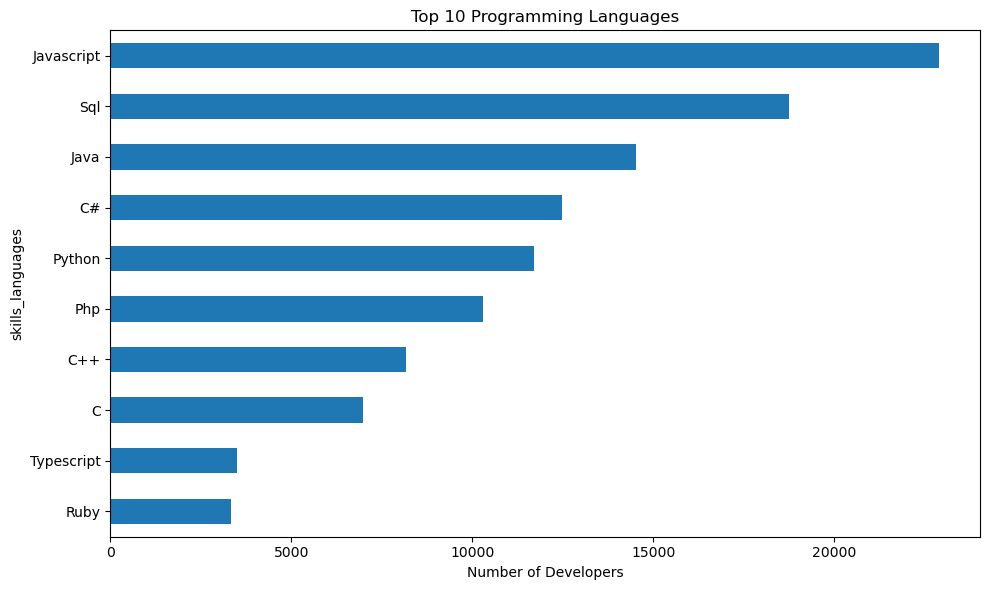

In [20]:
plt.figure(figsize=(10, 6))
top_languages.plot(kind='barh')
plt.xlabel('Number of Developers')
plt.title('Top 10 Programming Languages')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_languages.png', dpi=150)
plt.show()

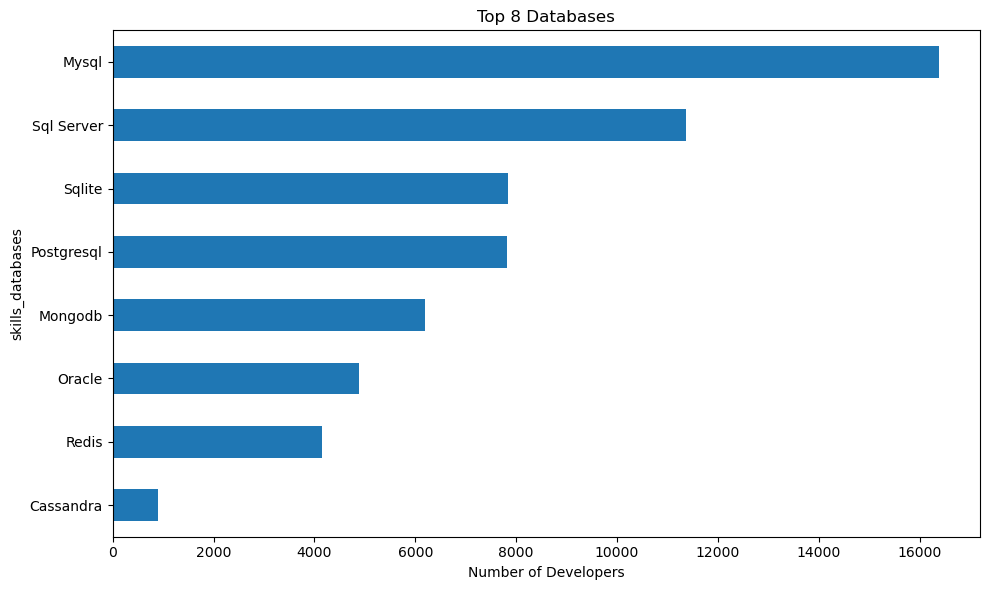

In [21]:
plt.figure(figsize=(10, 6))
top_databases.plot(kind='barh')
plt.xlabel('Number of Developers')
plt.title('Top 8 Databases')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_databases.png', dpi=150)
plt.show()

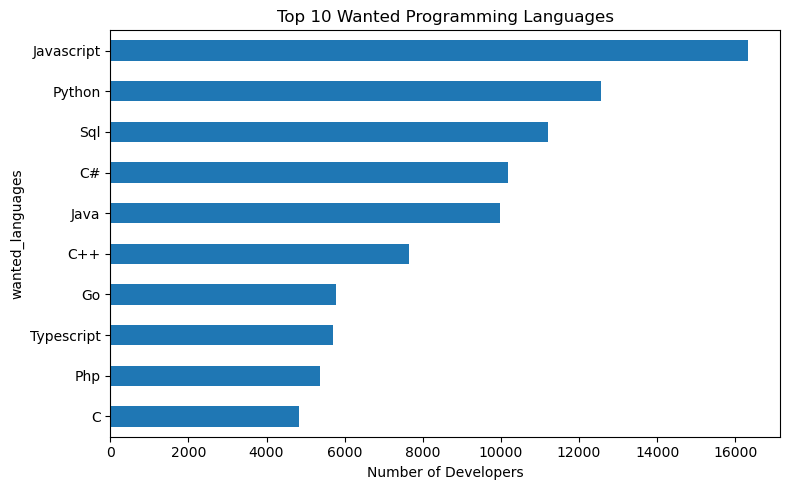

In [22]:
plt.figure(figsize=(8, 5))
top_wanted.plot(kind='barh')
plt.xlabel('Number of Developers')
plt.title('Top 10 Wanted Programming Languages')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_wanted.png', dpi=150)
plt.show()

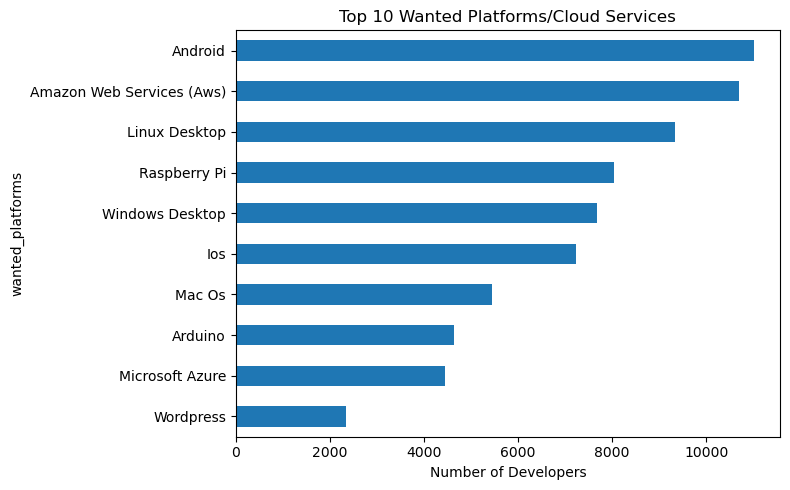

In [23]:
plt.figure(figsize=(8, 5))
top_platforms.plot(kind='barh')
plt.xlabel('Number of Developers')
plt.title('Top 10 Wanted Platforms/Cloud Services')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_platforms.png', dpi=150)
plt.show()

## 7. Hiring Priorities

What do employers value most? Compare across six categories.

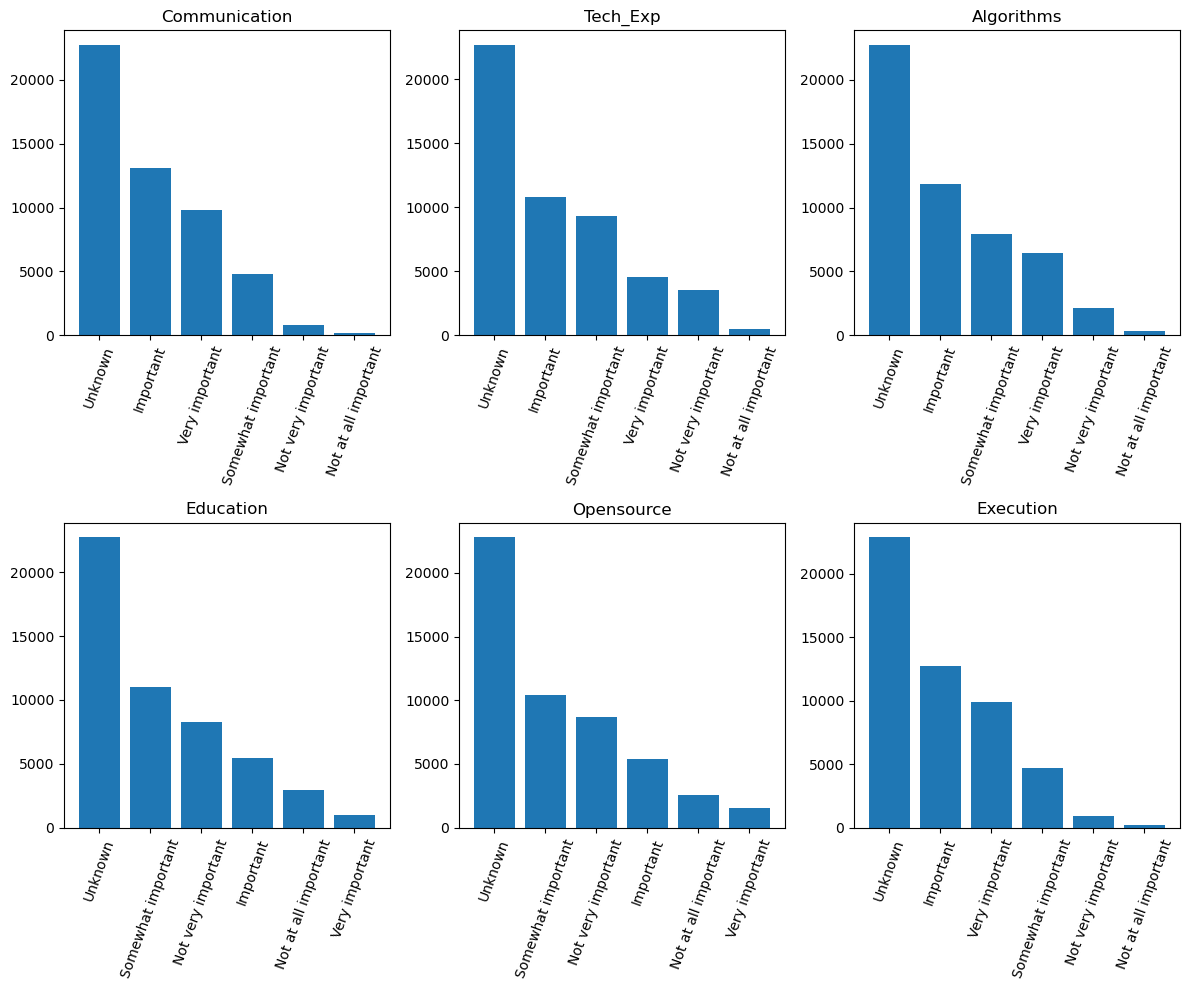

In [24]:
hiring_cols = ['hiring_communication', 'hiring_tech_exp', 'hiring_algorithms', 
               'hiring_education', 'hiring_opensource', 'hiring_execution']

fig, axes = plt.subplots(2, 3, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(hiring_cols):
    counts = df_clean[col].value_counts()
    axes[i].bar(counts.index, counts.values)
    axes[i].set_title(col.replace('hiring_', '').replace('_importance', '').title())
    axes[i].tick_params(axis='x', rotation=70)

plt.tight_layout()
plt.savefig('hiring_priorities.png', dpi=150)
plt.show()

## 8. Soft Skills

Non-technical skills: problem-solving, building things, learning new tech, investing time in tools, remote collaboration.

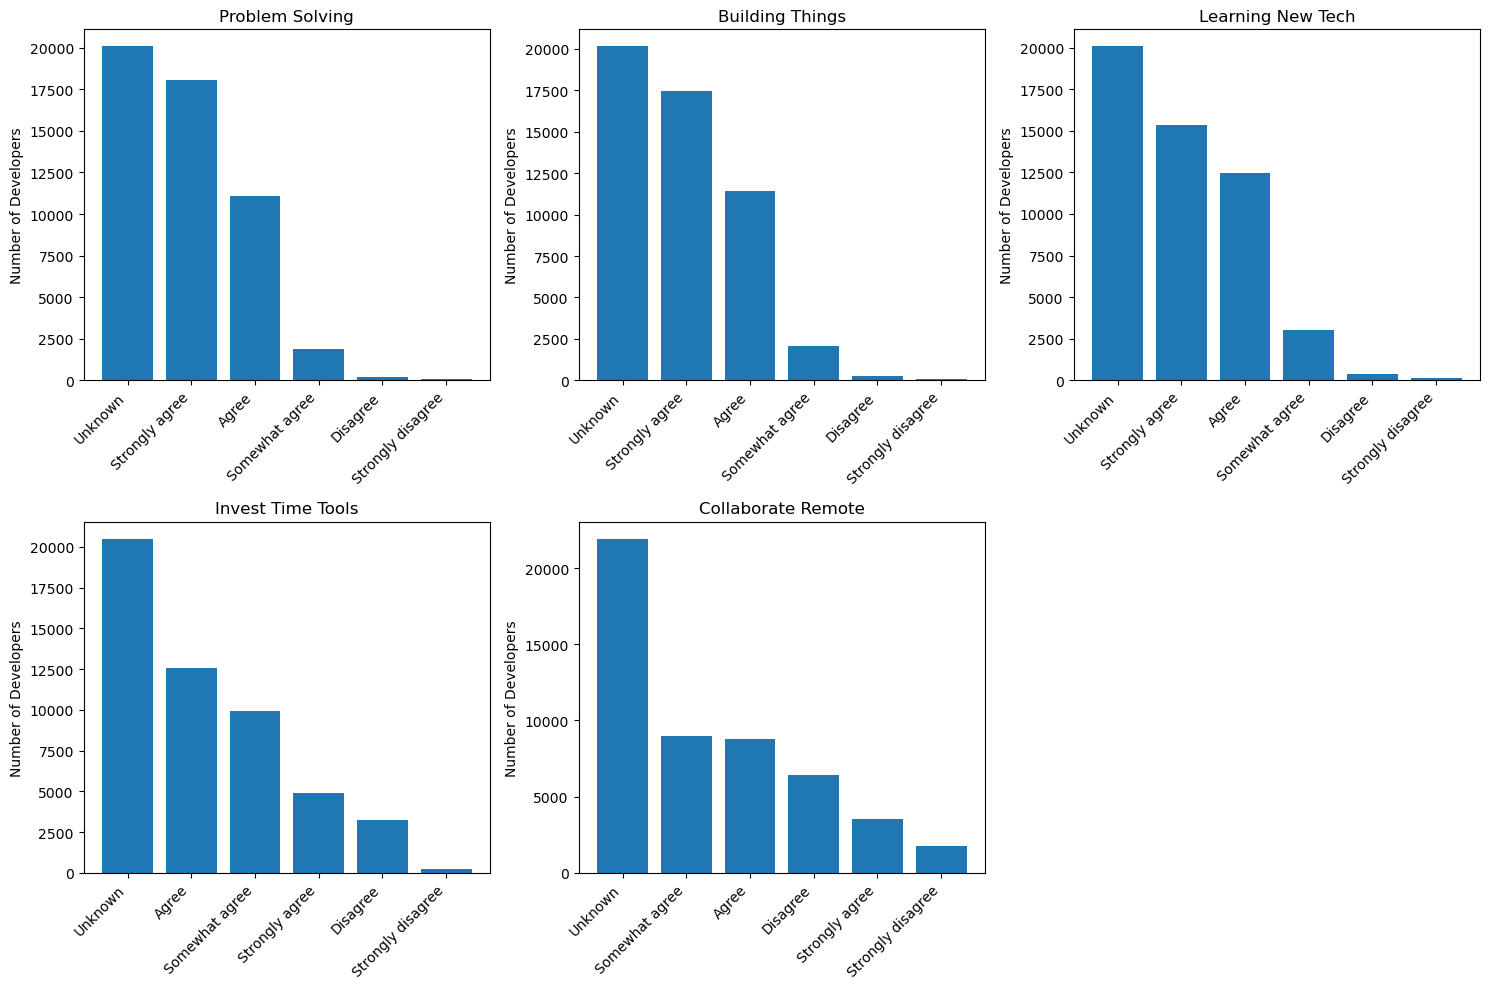

In [25]:
soft_skills = ['problem_solving', 'building_things', 'learning_new_tech', 
               'invest_time_tools', 'collaborate_remote']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, skill in enumerate(soft_skills):
    counts = df_clean[skill].value_counts()

    axes[i].bar(range(len(counts)), counts.values)
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(counts.index, rotation=45, ha='right')
    axes[i].set_title(skill.replace('_', ' ').title())
    axes[i].set_ylabel('Number of Developers')

axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('soft_skills.png', dpi=150)
plt.show()

## 9. Experience Distribution

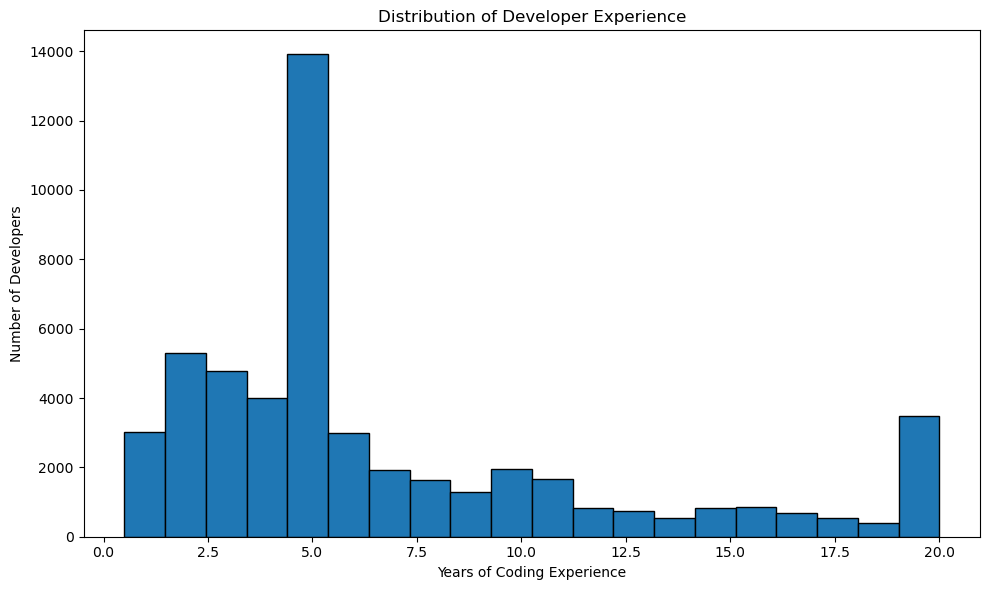

In [26]:
plt.figure(figsize=(10, 6))
plt.hist(df_clean['years_coding_numeric'], bins=20, edgecolor='black')
plt.xlabel('Years of Coding Experience')
plt.ylabel('Number of Developers')
plt.title('Distribution of Developer Experience')
plt.tight_layout()
plt.savefig('experience_distribution.png', dpi=150)
plt.show()

## 10. Country-Level Analysis

Compare the top 5 countries by developer count

In [27]:
top_countries = df_clean['country'].value_counts().head(5)
print(top_countries)

country
United States     11455
India              5197
United Kingdom     4395
Germany            4143
Canada             2233
Name: count, dtype: int64


In [28]:
from collections import Counter

# Get all job titles (excluding Not specified)
job_titles = df_clean[df_clean['job_title'] != 'Not specified']['job_title'].dropna()

# Split into words and count frequency
all_words = []
for title in job_titles:
    # Split by spaces and common separators
    words = str(title).lower().replace(';', ' ').replace('/', ' ').split()
    all_words.extend(words)

# Count word frequencies
word_counts = Counter(all_words)

# Show top 30 most common words
print("MOST COMMON WORDS IN JOB TITLES:")
for word, count in word_counts.most_common(30):
    print(f"   {word:14}: {count}")

MOST COMMON WORDS IN JOB TITLES:
   developer     : 52439
   web           : 26235
   applications  : 13787
   desktop       : 10435
   administrator : 9278
   mobile        : 8326
   specialist    : 5394
   database      : 5192
   with          : 4091
   a             : 4091
   statistics    : 4091
   or            : 4091
   mathematics   : 4091
   background    : 4091
   systems       : 4086
   devops        : 4015
   embedded      : 3352
   devices       : 3352
   data          : 3045
   scientist     : 3045
   other         : 2694
   graphics      : 1731
   programming   : 1731
   graphic       : 1426
   designer      : 1426
   machine       : 1379
   learning      : 1379
   quality       : 1252
   assurance     : 1252
   engineer      : 1252


In [29]:
# Create mapping based on actual keywords found
job_keywords = {
    'Web Developer': ['web'],
    'Desktop Developer': ['desktop', 'desktop applications'],
    'Mobile Developer': ['mobile'],
    'Database Administrator': ['database', 'administrator', 'dba'],
    'Systems Administrator': ['systems', 'system admin'],
    'DevOps Engineer': ['devops'],
    'Embedded Developer': ['embedded', 'devices'],
    'Data Scientist': ['data scientist', 'statistics', 'mathematics'],
    'Machine Learning': ['machine learning', 'ml'],
    'Graphics Developer': ['graphics', 'graphic', 'programming'],
    'Graphic Designer': ['graphic designer'],
    'QA Engineer': ['quality', 'assurance', 'qa'],
    'Other': []
}

def extract_job_category(job_title):
    if pd.isna(job_title) or job_title == 'Not specified':
        return 'Not specified'
    
    job_lower = str(job_title).lower()
    
    for category, keywords in job_keywords.items():
        for keyword in keywords:
            if keyword in job_lower:
                return category
    
    return 'Other'

# Apply
df_clean['job_category'] = df_clean['job_title'].apply(extract_job_category)

# Check distribution
print("JOB CATEGORY DISTRIBUTION:")
print(df_clean['job_category'].value_counts())

JOB CATEGORY DISTRIBUTION:
job_category
Web Developer             26235
Not specified             15267
Desktop Developer          3626
Mobile Developer           1983
Data Scientist             1175
Other                      1174
Embedded Developer          856
Database Administrator      504
DevOps Engineer             326
QA Engineer                 109
Graphics Developer           78
Machine Learning             59
Name: count, dtype: int64


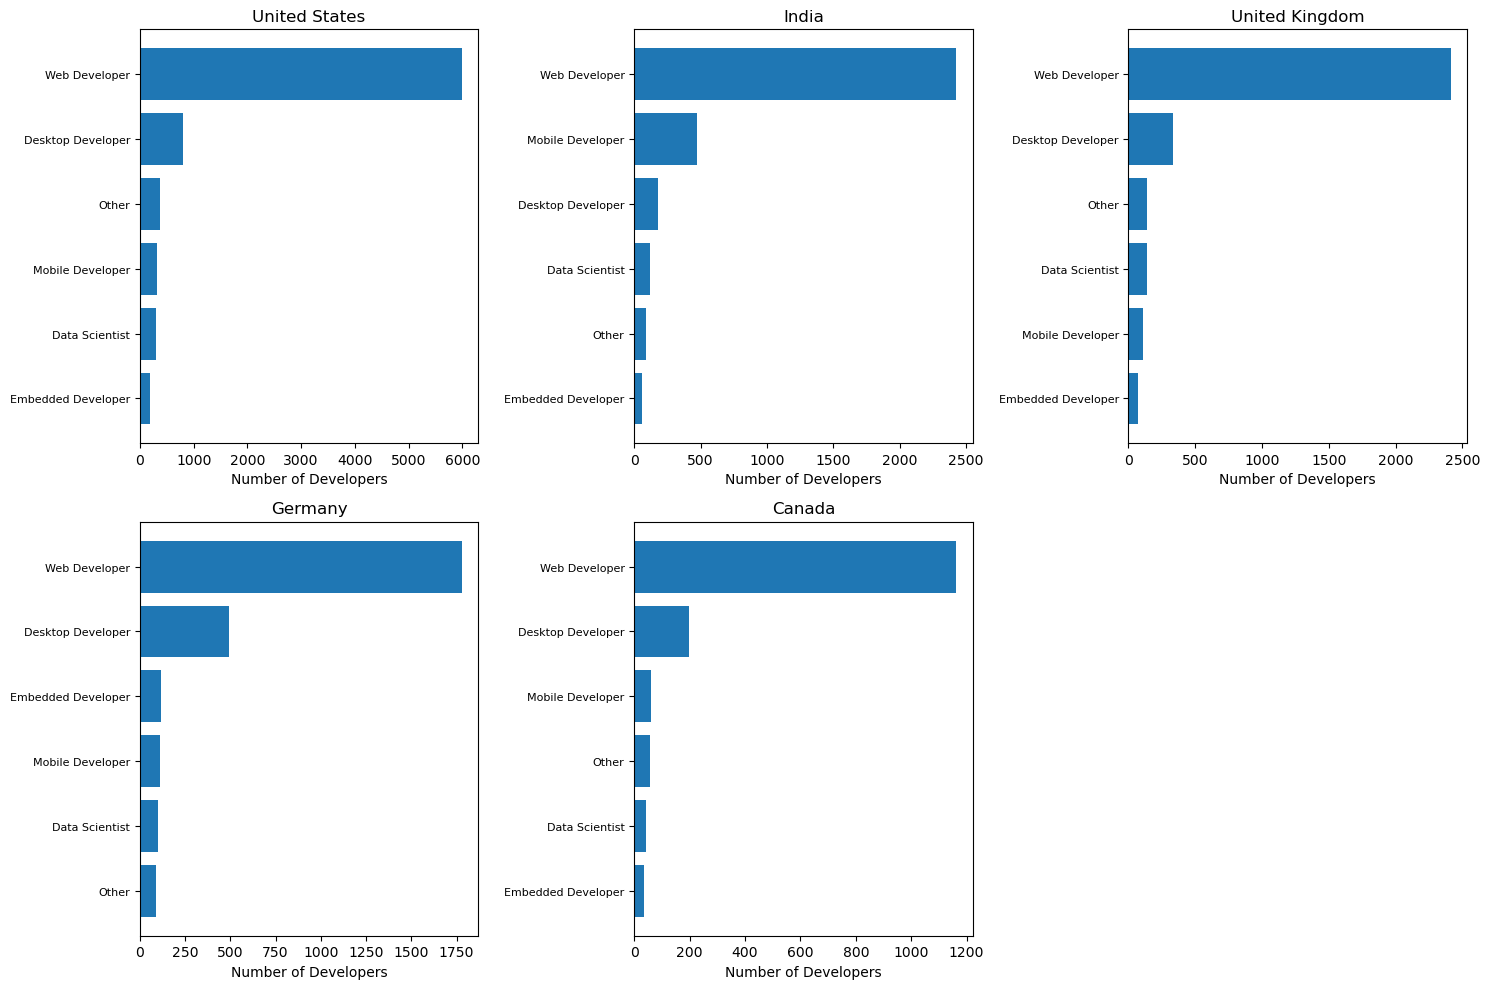

In [30]:
# Define top countries
top_countries = df_clean['country'].value_counts().head(5).index

# Create plot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, country in enumerate(top_countries):
    country_data = df_clean[df_clean['country'] == country]
    country_data = country_data[country_data['job_category'] != 'Not specified']
    
    top_cats = country_data['job_category'].value_counts().head(6)
    
    axes[i].barh(range(len(top_cats)), top_cats.values)
    axes[i].set_yticks(range(len(top_cats)))
    axes[i].set_yticklabels(top_cats.index, fontsize=8)
    axes[i].set_xlabel('Number of Developers')
    axes[i].set_title(f'{country}')
    axes[i].invert_yaxis()

# Hide unused subplot
if len(top_countries) < 6:
    axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('job_categories_by_country.png', dpi=150)
plt.show()

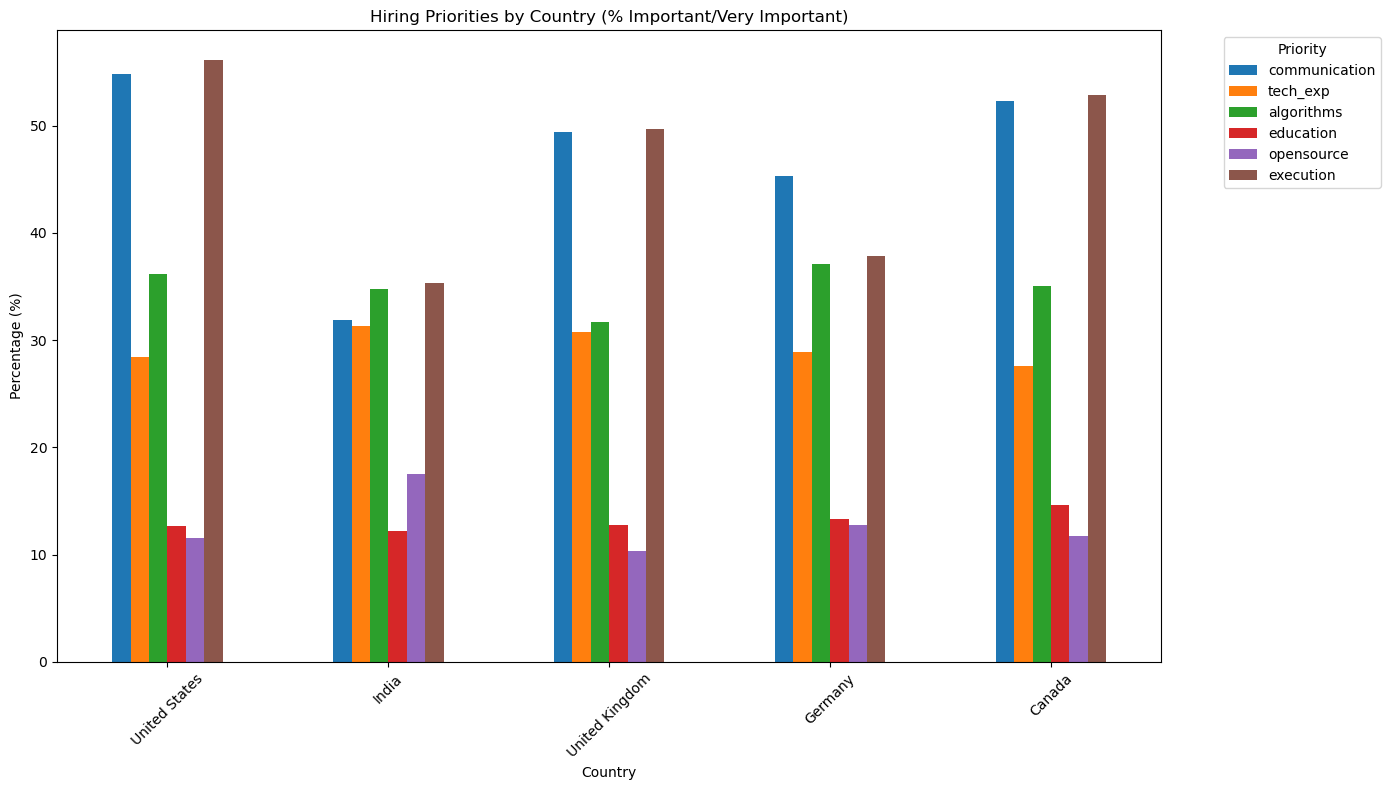

In [31]:
top_countries = df_clean['country'].value_counts().head(5).index

hiring_comparison = {}

for country in top_countries:
    country_data = df_clean[df_clean['country'] == country]
    hiring_comparison[country] = {}
    
    for col in hiring_cols:
        counts = country_data[col].value_counts()
        important_pct = (counts.get('Important', 0) + counts.get('Very important', 0)) / len(country_data) * 100
        hiring_comparison[country][col.replace('hiring_', '').replace('_importance', '')] = important_pct

hiring_df = pd.DataFrame(hiring_comparison).T

fig, ax = plt.subplots(figsize=(14, 8))
hiring_df.plot(kind='bar', ax=ax)
plt.xlabel('Country')
plt.ylabel('Percentage (%)')
plt.title('Hiring Priorities by Country (% Important/Very Important)')
plt.legend(title='Priority', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('hiring_by_country.png', dpi=150)
plt.show()

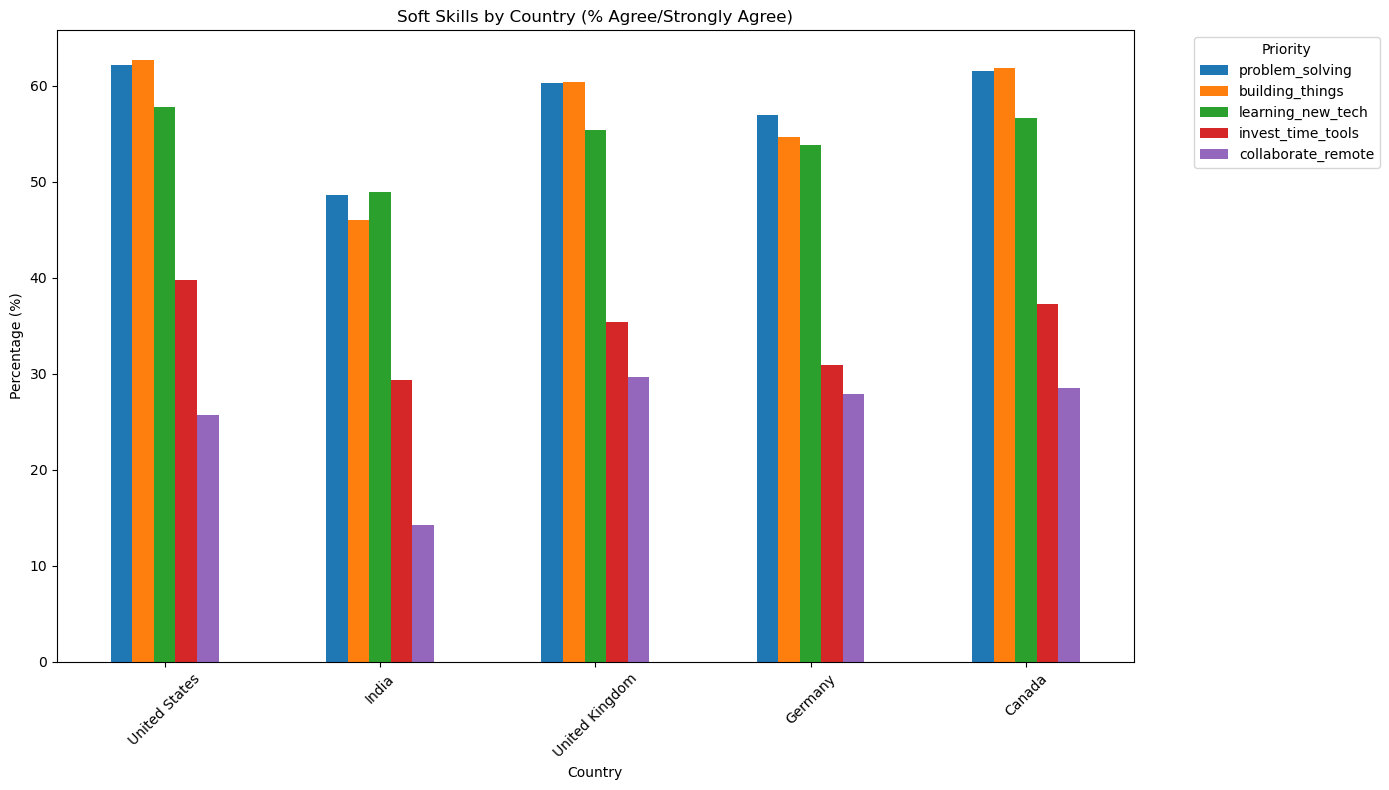

In [32]:
softskills_comparison = {}

for country in top_countries:
    country_data = df_clean[df_clean['country'] == country]
    softskills_comparison[country] = {}
    
    for col in soft_skills:
        counts = country_data[col].value_counts()

        important_pct = (counts.get('Strongly agree', 0) + counts.get('Agree', 0)) / len(country_data) * 100
        softskills_comparison[country][col]= important_pct

soft_df = pd.DataFrame(softskills_comparison).T

fig, ax = plt.subplots(figsize=(14, 8))
soft_df.plot(kind='bar', ax=ax)
plt.xlabel('Country')
plt.ylabel('Percentage (%)')
plt.title('Soft Skills by Country (% Agree/Strongly Agree)')
plt.legend(title='Priority', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('soft_by_country.png', dpi=150)
plt.show()

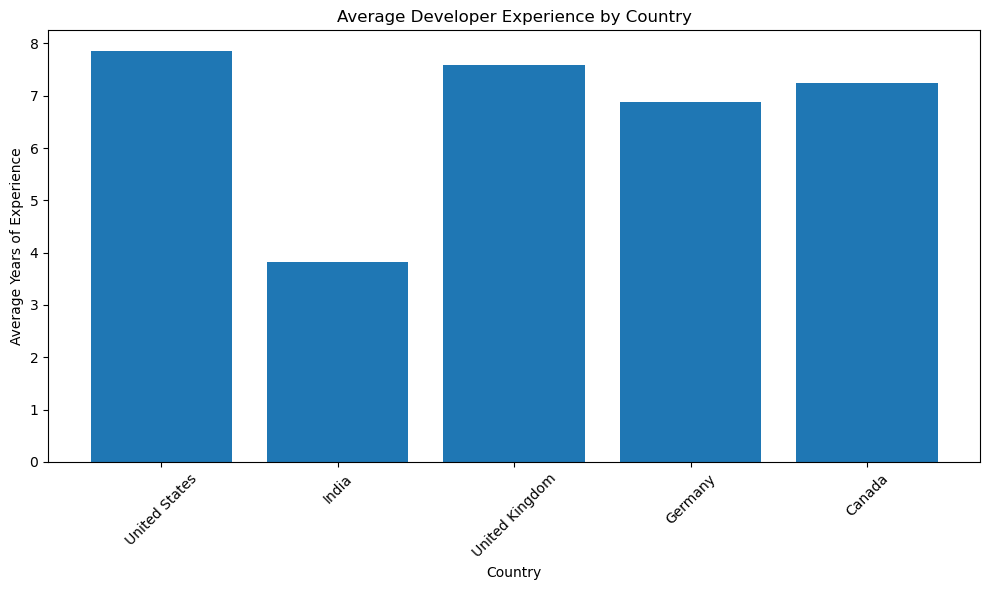


 AVERAGE EXPERIENCE BY COUNTRY:
   United States: 7.9 years
   India: 3.8 years
   United Kingdom: 7.6 years
   Germany: 6.9 years
   Canada: 7.2 years


In [33]:
# Compare experience across top countries
top_countries = df_clean['country'].value_counts().head(5).index

exp_by_country = {}
for country in top_countries:
    country_data = df_clean[df_clean['country'] == country]
    exp_by_country[country] = country_data['years_coding_numeric'].mean()

# Plot
plt.figure(figsize=(10, 6))
plt.bar(exp_by_country.keys(), exp_by_country.values())
plt.xlabel('Country')
plt.ylabel('Average Years of Experience')
plt.title('Average Developer Experience by Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('experience_by_country.png', dpi=150)
plt.show()

print("\n AVERAGE EXPERIENCE BY COUNTRY:")
for country, avg_exp in exp_by_country.items():
    print(f"   {country}: {avg_exp:.1f} years")

In [34]:
for country in top_countries:
    country_data = df_clean[df_clean['country'] == country]
    country_data = country_data[country_data['skills_languages'] != '']
    
    skills = (country_data['skills_languages']
            .str.split(';')
            .explode()
            .str.strip()      
            .str.title()      
            .value_counts()
            .head(5))
    
    print(f"\n{country} TOP SKILLS:")
    for skill, count in skills.items():
        print(f"{skill:14}: {count}")


United States TOP SKILLS:
Javascript    : 5699
Sql           : 4589
Python        : 3348
Java          : 3191
C#            : 3100

India TOP SKILLS:
Javascript    : 1580
Java          : 1378
Sql           : 1373
Php           : 885
C             : 817

United Kingdom TOP SKILLS:
Javascript    : 2214
Sql           : 1849
C#            : 1386
Python        : 1038
Java          : 940

Germany TOP SKILLS:
Javascript    : 1770
Java          : 1458
Sql           : 1450
C#            : 953
Python        : 947

Canada TOP SKILLS:
Javascript    : 1104
Sql           : 872
C#            : 647
Python        : 620
Java          : 613


In [35]:
for country in top_countries:
    country_data = df_clean[df_clean['country'] == country]
    country_data = country_data[country_data['wanted_languages'] != '']
    
    want = (country_data['wanted_languages']
            .str.split(';')
            .explode()
            .value_counts()
            .head(5))
    
    print(f"\n{country} WANTS TO LEARN:")
    for skill, count in want.items():
        print(f"{skill:14}: {count}")


United States WANTS TO LEARN:
 JavaScript   : 3225
 Python       : 3031
 SQL          : 2750
C#            : 1847
 Java         : 1419

India WANTS TO LEARN:
 JavaScript   : 995
 Python       : 994
 SQL          : 893
Java          : 535
 Java         : 533

United Kingdom WANTS TO LEARN:
 JavaScript   : 1193
 SQL          : 1037
 Python       : 939
C#            : 836
 TypeScript   : 566

Germany WANTS TO LEARN:
 JavaScript   : 902
 SQL          : 849
 Python       : 830
 Java         : 550
C#            : 498

Canada WANTS TO LEARN:
 JavaScript   : 618
 Python       : 561
 SQL          : 540
C#            : 378
 TypeScript   : 265


In [36]:
def get_top_values_by_country(df, country, column_name, n=5):
    """Get top n values for a specific country"""
    country_data = df[df['country'] == country]
    return (country_data[column_name]
            .str.split(';')
            .explode()
            .str.strip()
            .str.title()
            .dropna()
            .pipe(lambda x: x[x != ''])
            .value_counts()
            .head(n))

## 11. Key Findings

### Global
- **Most used language:** JavaScript (~22,875 developers)
- **Most wanted language:** JavaScript (~16,327 want to learn)
- **Largest skill gap:** Go — wanted by ~5,770, currently used by ~1,557 (gap ~4,213)
- **Most common job title:** Web Developer (~10,683 developers)
- **Top database:** SQL (across all regions)

### Top 5 countries

| Country | Top Language | Top Wanted | Top Hiring Priority | Avg. Experience |
|---------|-------------|------------|---------------------|-----------------|
| United States | JavaScript | JavaScript | Communication (55%) | 7.9 years |
| India | JavaScript | JavaScript | Algorithms (35%) | 3.8 years |
| United Kingdom | JavaScript | JavaScript | Communication (49%) | 7.6 years |
| Germany | JavaScript | JavaScript | Communication (45%) | 6.9 years |
| Canada | JavaScript | JavaScript | Communication (52%) | 7.2 years |

### Insights
- **JavaScript dominates globally** both current usage and future learning intent, across every top country.
- **Communication is the #1 hiring priority** in 4 of 5 countries, ahead of algorithms and formal education.
- **India's developers average 3.8 years** of experience roughly half of Western countries (7+ years).
- **Building Things** is the top self-reported soft skill in most English-speaking countries.
- **Go has the largest demand-supply gap** a strong signal for what to learn next.

### Limitations
- Survey data is self-reported and biased toward Stack Overflow's user base.
- Salary columns were excluded due to currency inconsistency and sparse coverage.
- No real-time market signals (job postings, GitHub activity) — a potential future enhancement.